In [1]:
#Importing packages
from torch.utils.data import DataLoader
import torch
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm
import pandas as pd
from chromadb import PersistentClient as PersistentClient
from chromadb.errors import InternalError as CollectionError

#library functions
import helper_code.dataloading as dataloading
import helper_code.data_vis as data_vis
import helper_code.model_functions as model_functions
import helper_code.loss_functions as loss_functions
import helper_code.models as models
from helper_code.seeds import set_seed


d:\Projects\alertcalifornia-anomaly-detection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
g = set_seed()

In [3]:
labels_csv = r"camera_data/all_data_4pt.csv"

device = 'cuda'

model_path = 'weights/'
model_name = "triplet_loss_all_init_model.pth"

data = dataloading.get_data(labels_csv, 'camera_data/images/', replace_images = False, binarize=True)
train, val, test = dataloading.get_train_val_test(data = data, output_csvs=True)
train_dataloader, val_dataloader, test_dataloader = dataloading.get_train_val_test_dataloaders(train, val, test, generator = g)

100%|██████████| 6270/6270 [00:01<00:00, 4871.14it/s]


In [4]:
def run_model(lr, margin, num_epochs, head_num_epochs, head_lr, model_name):
    encoder = models.create_encoder()
    encoder.to(device)
    encoder.load_state_dict(torch.load('weights/model_weights_camera_10-27-25.pth', map_location=device, weights_only=True))

    loss_func = loss_func = loss_functions.triplet_loss(margin=margin)
    optimizer = optim.Adam(encoder.parameters(), lr=lr) 

    losses = model_functions.train_model(encoder, train_data=train_dataloader, 
                                num_epochs=num_epochs, loss_func=loss_func, 
                                optimizer=optimizer, name = model_name, path = 'weights/', device=device)
    

    client = PersistentClient(path="embedding_data/") 

    try:
        client.delete_collection(name="train_embeddings")
    except Exception:
        pass

    try:
        client.delete_collection(name="val_embeddings")
    except Exception:
        pass


    dataloading.save_full_embeddings(encoder, train_dataloader, 
                            "train_embeddings", persist_directory = "embedding_data/", 
                            device = device)


    dataloading.save_full_embeddings(encoder, val_dataloader, 
                            "val_embeddings", persist_directory = "embedding_data/", 
                            device = device)
        
    #Embeddings of training data, used to train the classification head
    train_embeddings, train_labels, _, _ = dataloading.load_full_embeddings(train, "train_embeddings", persist_directory = "embedding_data/")
    train_embedding_dataloader = dataloading.embedding_to_dataloader(train_embeddings, train_labels, batch_size=32, generator = g)

    val_embeddings, val_labels, _, _ = dataloading.load_full_embeddings(val, "val_embeddings", persist_directory = "embedding_data/")

    reduced_embeddings, labels = model_functions.reduce_pca(train_embeddings, train_labels, dimensions=4)

    classification_head = models.ClassificationHead(num_classes=2)
    classification_head.to(device)

    head_criterion = nn.CrossEntropyLoss()
    head_optimizer = optim.Adam(classification_head.parameters(), lr=head_lr) # Optimize only the new head

    losses = model_functions.train_classification_head(classification_head, train_embedding_dataloader, num_epochs=head_num_epochs, criterion=head_criterion, optimizer=head_optimizer, 
                                                       device=device, model_name=model_name, model_path = "weights/", save=True)

    train_accuracy = model_functions.get_classification_accuracy(train_embeddings, train_labels, classification_head, device)
    val_accuracy = model_functions.get_classification_accuracy(val_embeddings, val_labels, classification_head, device)


    return losses, reduced_embeddings, labels, train_accuracy, val_accuracy

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Processing batch 117 in epoch 0: : 118it [01:37,  1.21it/s]
Processing batches in epoch 0: 100%|██████████| 118/118 [00:23<00:00,  5.00it/s]
Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Processing batch 117 in epoch 0: : 118it [01:38,  1.20it/s]
Processing batch 117 in epoch 1: : 118it [01:36,  1.23it/s]
Processing batch 117 in epoch 2: : 118it [01:36,  1.23it/s]
Processing batch 117 in epoch 3: : 118it [01:35,  1.23it/s]
Processing batch 117 in epoch 4: : 118it [01:38

KeyboardInterrupt: 

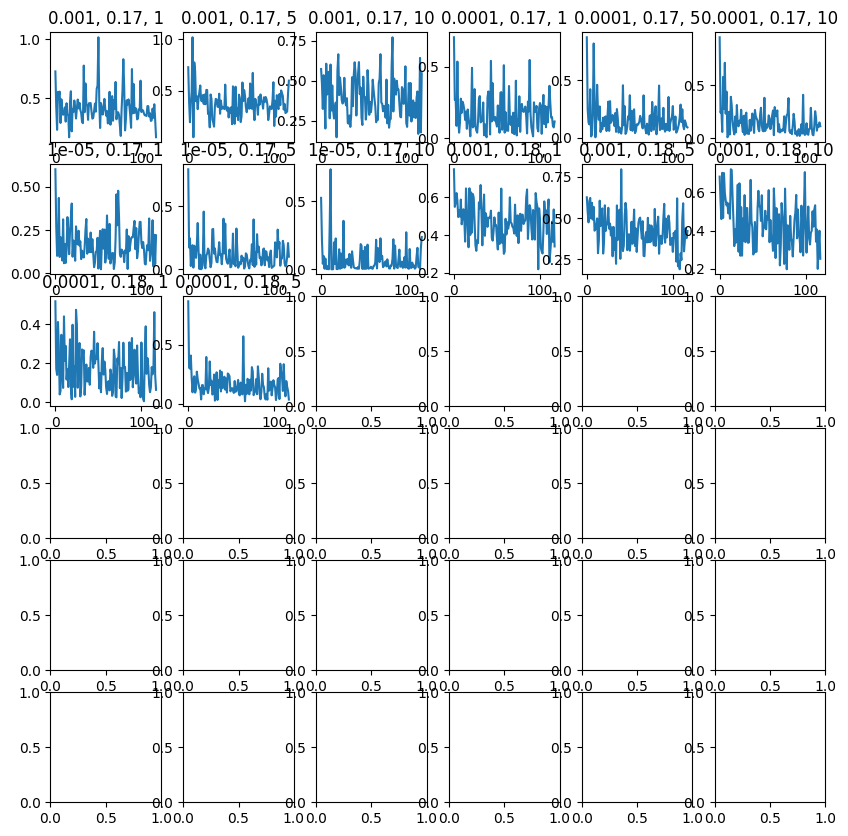

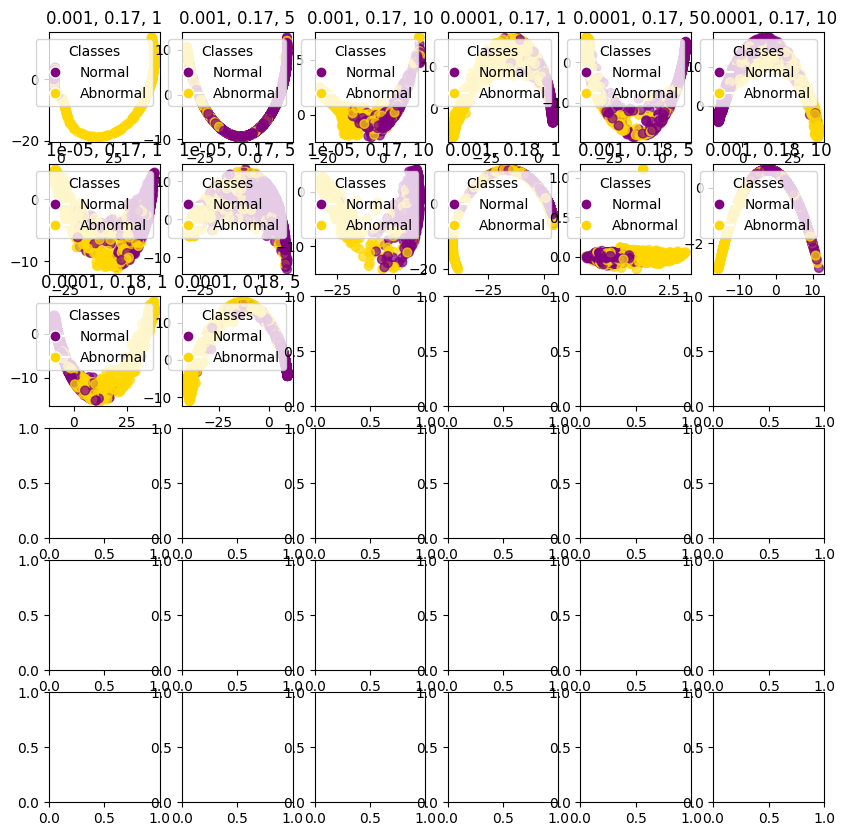

In [ ]:
from itertools import product
import matplotlib.pyplot as plt

margins = [0.17, 0.18, 0.19, 0.20]
lrs = [1e-3, 1e-4, 1e-5]
nums_epochs = [1,5,10]
#head_num_epochs = [1,5,10]
#head_lrs = [1e-2, 1e-3, 1e-4, 1e-5]

combinations = list(product(margins, lrs, nums_epochs))

accuracies_df = pd.DataFrame(index = pd.MultiIndex.from_tuples(combinations, 
                                                               names = ["Margin", "Learning Rate", "Number of Epochs"]), 
                                                               columns = ["Train Accuracy", "Val Accuracy"])


fig_losses, ax_losses = plt.subplots(6, 6, figsize=(10, 10))
fig_embeddings, ax_embeddings = plt.subplots(6, 6, figsize=(10, 10))
for i, (margin, lr, num_epochs) in enumerate(combinations):
    losses, reduced_embeddings, labels, train_accuracy, val_accuracy = run_model(lr, margin, num_epochs, head_num_epochs=5, head_lr=1e-3,
                                                                                   model_name=f"model_{margin}_{lr}_{num_epochs}")


    ax_losses[i//6, i%6].plot(list(range(len(losses))), losses)
    ax_losses[i//6, i%6].set_title(f"{lr}, {margin}, {num_epochs}")

    ax_embeddings[i//6, i%6] = data_vis.plot_data(reduced_embeddings, labels, 
                                                  ax=ax_embeddings[i//6, i%6], 
                                                  title=f"{lr}, {margin}, {num_epochs}")
    

    accuracies_df.loc[(margin, lr, num_epochs), "Train Accuracy"] = train_accuracy
    accuracies_df.loc[(margin, lr, num_epochs), "Val Accuracy"] = val_accuracy


print("Displaying losses...")
fig_losses.show()
#print("Displaying embeddings...")
#fig_embeddings.show()

accuracies_df

Instantiating the pre-trained model

In [6]:
accuracies_df

Train Accuracy Val Accuracy
Margin Learning Rate Number of Epochs                            
0.17   0.00100       1                      0.855889     0.858054
                     5                      0.862005     0.859649
                     10                      0.85908     0.866029
       0.00010       1                      0.948684     0.942584
                     5                      0.951875     0.931419
                     10                     0.945759     0.935407
       0.00001       1                      0.951343     0.939394
                     5                      0.966232     0.951356
                     10                     0.983781     0.951356
0.18   0.00100       1                      0.847913     0.857257
                     5                      0.848445      0.85327
                     10                     0.844988     0.847687
       0.00010       1                      0.950545     0.944976
                     5                      0.947089     0.933014
                     10                          NaN          NaN
       0.00001       1                           NaN          NaN
                     5                           NaN          NaN
                     10                          NaN          NaN
0.19   0.00100       1                           NaN          NaN
                     5                           NaN          NaN
                     10                          NaN          NaN
       0.00010       1                           NaN          NaN
                     5                           NaN          NaN
                     10                          NaN          NaN
       0.00001       1                           NaN          NaN
                     5                           NaN          NaN
                     10                          NaN          NaN
0.20   0.00100       1                           NaN          NaN
                     5                           NaN          NaN
                     10                          NaN          NaN
       0.00010       1                           NaN          NaN
                     5                           NaN          NaN
                     10                          NaN          NaN
       0.00001       1                           NaN          NaN
                     5                           NaN          NaN
                     10                          NaN          NaN

In [5]:
encoder = models.create_encoder()
encoder.to(device)
encoder.load_state_dict(torch.load('weights/model_weights_camera_10-27-25.pth', map_location=device, weights_only=True));

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Instantiating the training settings

In [6]:
loss_func = loss_functions.TripletMarginLoss(margin = 0.17)
optimizer = optim.Adam(encoder.parameters(), lr=1e-6) 
num_epochs = 10

Training the model

In [7]:
losses = model_functions.train_model(encoder, train_data=train_dataloader, 
                                num_epochs=num_epochs, loss_func=loss_func, 
                                optimizer=optimizer, name = 'triplet_loss_init_model.pth', path = 'weights/', device=device)

Processing batch 117 in epoch 0: : 118it [01:40,  1.17it/s]
Processing batch 117 in epoch 1: : 118it [01:37,  1.21it/s]
Processing batch 117 in epoch 2: : 118it [01:37,  1.21it/s]
Processing batch 117 in epoch 3: : 118it [01:37,  1.21it/s]
Processing batch 117 in epoch 4: : 118it [01:37,  1.21it/s]
Processing batch 117 in epoch 5: : 118it [01:37,  1.21it/s]
Processing batch 117 in epoch 6: : 118it [01:37,  1.21it/s]
Processing batch 117 in epoch 7: : 118it [01:37,  1.21it/s]
Processing batch 117 in epoch 8: : 118it [01:37,  1.21it/s]
Processing batch 117 in epoch 9: : 118it [01:37,  1.21it/s]


Text(0.5, 1.0, 'Image to Embeddings Model Losses')

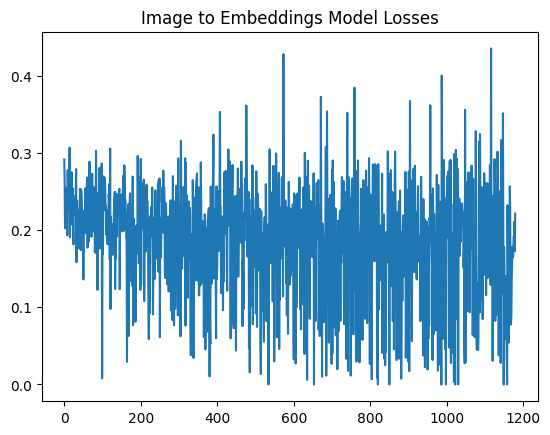

In [8]:
import matplotlib.pyplot as plt

plt.plot(list(range(len(losses))), losses)
plt.title("Image to Embeddings Model Losses")

Saving the embeddings generated by this model

In [9]:
client = PersistentClient(path="embedding_data/") 

try:
    client.delete_collection(name="train_embeddings")
except Exception:
    pass

try:
    client.delete_collection(name="val_embeddings")
except Exception:
    pass


dataloading.save_full_embeddings(encoder, train_dataloader, 
                        "train_embeddings", persist_directory = "embedding_data/", 
                        device = device)


dataloading.save_full_embeddings(encoder, val_dataloader, 
                        "val_embeddings", persist_directory = "embedding_data/", 
                        device = device)
    
    
#Embeddings of training data, used to train the classification head
train_embeddings, train_labels, train_img_urls, train_a_ids = dataloading.load_full_embeddings(train, "train_embeddings", persist_directory = "embedding_data/")
train_embedding_dataloader = dataloading.embedding_to_dataloader(train_embeddings, train_labels, batch_size=32, generator = g)

#Embeddings of validation data, used to display results
val_embeddings, val_labels, val_img_urls, val_a_ids = dataloading.load_full_embeddings(val, "val_embeddings", persist_directory = "embedding_data/")

Visualizing the first two principal axes of the embedding space

In [10]:
reduced_embeddings, labels = model_functions.reduce_pca(train_embeddings, train_labels, dimensions=5)

#idx = (labels == 3).to_numpy()
#reduced_embeddings = reduced_embeddings[idx]
#labels = labels[idx]

In [16]:
pd.DataFrame(reduced_embeddings).to_csv("camera_data/reduced_embeddings_all.csv", index=False)

In [17]:
pd.DataFrame({"labels": train_labels, "img_urls": train_img_urls, "annotation_ids": train_a_ids}).to_csv("camera_data/labels_urls_ids_all.csv", index=False)

In [11]:
pd.Series(labels).value_counts()

label
0    2845
1     916
Name: count, dtype: int64

Text(0.5, 1.0, 'First two axes of embedding space')

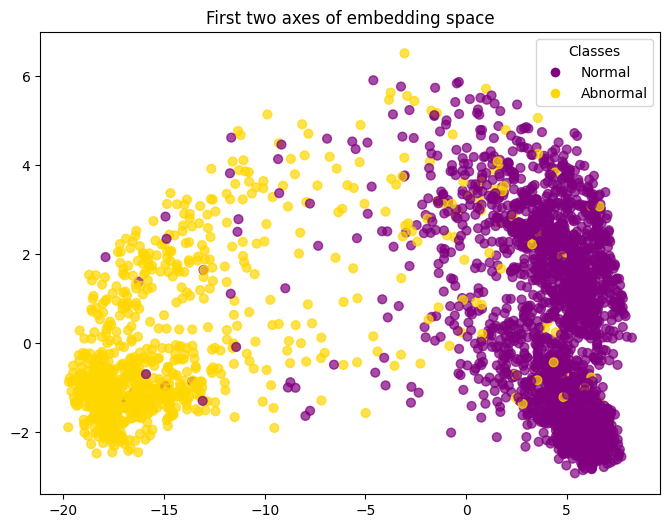

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
ax = data_vis.plot_data(reduced_embeddings, labels, pcx = 1, pcy = 2, ax=ax)
ax.set_title("First two axes of embedding space")

Training classification head

In [13]:
losses = []

classification_head = models.ClassificationHead()
classification_head.to(device)

head_criterion = nn.CrossEntropyLoss()
head_optimizer = optim.Adam(classification_head.parameters(), lr=1e-3) # Optimize only the new head

losses = model_functions.train_classification_head(classification_head, train_embedding_dataloader, num_epochs=15, criterion=head_criterion, optimizer=head_optimizer, 
                           device=device, model_name=model_name, model_path = "weights/", save=True)

#Report training and validation accuracy
classification_head.eval()

Processing batches in epoch 0: 100%|██████████| 118/118 [00:23<00:00,  5.08it/s]


ClassificationHead(
  (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (head): Sequential(
    (0): Linear(in_features=768, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=4, bias=True)
  )
)

Testing classification head outputs

In [14]:
train_embeddings_tensor = torch.Tensor(train_embeddings.to_numpy()).to(device)
val_embeddings_tensor = torch.Tensor(val_embeddings.to_numpy()).to(device)

train_labels_tensor = torch.Tensor(train_labels.to_numpy()).to(device)
val_labels_tensor = torch.Tensor(val_labels.to_numpy()).to(device)


train_outputs = classification_head(train_embeddings_tensor)
val_outputs = classification_head(val_embeddings_tensor)

print(f"Training accuracy: {(torch.argmax(train_outputs, dim = -1) == train_labels_tensor).float().mean().item()}")
print(f"Validation accuracy: {(torch.argmax(val_outputs, dim = -1) == val_labels_tensor).float().mean().item()}")

Training accuracy: 0.965966522693634
Validation accuracy: 0.9370015859603882


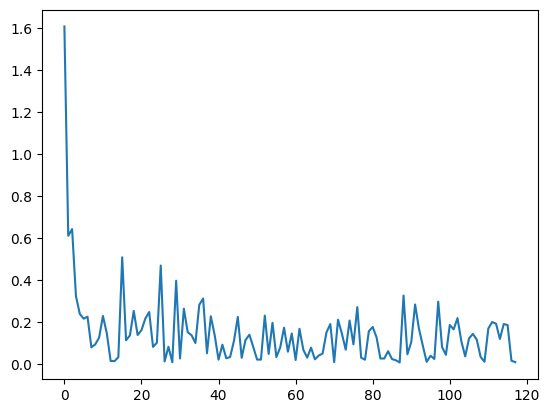

In [15]:
plt.plot(list(range(len(losses))), losses)

In [23]:
def get_val_embeddings(label_data, loc_name, model):    
    data = dataloading.get_data(label_data, 'camera_data/images/', replace_images = False, binarize=True)
    train, val, test = dataloading.get_train_val_test(data = data, output_csvs=True)
    _, val_dataloader, _ = dataloading.get_train_val_test_dataloaders(train, val, test, generator = g)

    client = PersistentClient(path="embedding_data/") 

    try:
        client.delete_collection(name=f"{loc_name}_val_embeddings")
    except Exception:
        pass

    dataloading.save_full_embeddings(model, val_dataloader, 
                        f"{loc_name}_val_embeddings", persist_directory = "embedding_data/", 
                        device = device)
    
    val_embeddings, val_labels, val_img_urls, val_a_ids = dataloading.load_full_embeddings(val, f"{loc_name}_val_embeddings", persist_directory = "embedding_data/")

    return val_embeddings, val_labels, val_img_urls, val_a_ids

100%|██████████| 2314/2314 [00:00<00:00, 7070.05it/s]


Validation accuracy for coronado_hills: 0.9546436071395874


100%|██████████| 1914/1914 [00:00<00:00, 2883.09it/s]


Validation accuracy for mesa_grande: 0.9712793827056885


100%|██████████| 2042/2042 [00:00<00:00, 6710.99it/s]


Validation accuracy for palomar: 0.9462103247642517


C:\Users\Aneesh\AppData\Local\Temp\ipykernel_7548\1856579907.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


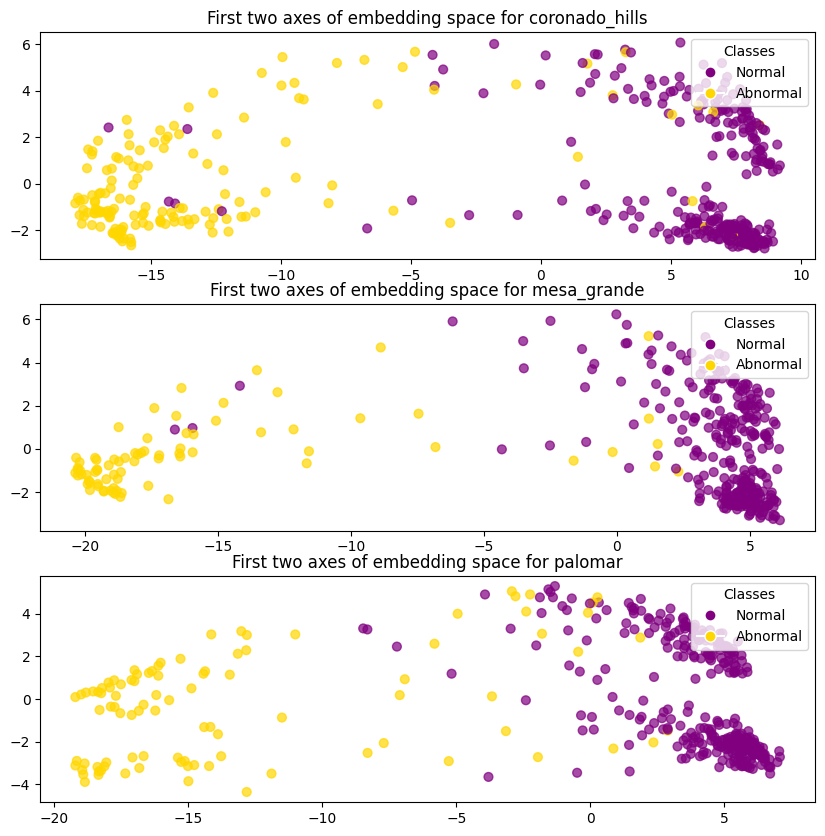

In [28]:
coronado_fp = r"camera_data/images/coronado_hills_4pt.csv"
mesa_grande_fp = r"camera_data/images/mesa_grande_4pt.csv"
palomar_fp = r"camera_data/images/palomar_4pt.csv"

fig, ax = plt.subplots(3, 1, figsize=(10, 10))
for i, location in enumerate(["coronado_hills", "mesa_grande", "palomar"]):
    val_embeddings, val_labels, val_img_urls, val_a_ids = get_val_embeddings(f"camera_data/{location}_4pt.csv", location, encoder)
    reduced_embeddings, labels = model_functions.reduce_pca(val_embeddings, val_labels, dimensions=5)
    
    ax[i] = data_vis.plot_data(reduced_embeddings, labels, pcx = 1, pcy = 2, ax=ax[i])
    ax[i].set_title(f"First two axes of embedding space for {location}")

    pd.DataFrame(reduced_embeddings).to_csv(f"camera_data/reduced_embeddings_{location}.csv", index=False)
    pd.DataFrame({"labels": labels, "img_urls": val_img_urls, "annotation_ids": val_a_ids}).to_csv(f"camera_data/labels_urls_ids_{location}.csv", index=False)

    val_embeddings_tensor = torch.Tensor(val_embeddings.to_numpy()).to(device)

    val_labels_tensor = torch.Tensor(val_labels.to_numpy()).to(device)

    val_outputs = classification_head(val_embeddings_tensor)

    print(f"Validation accuracy for {location}: {(torch.argmax(val_outputs, dim = -1) == val_labels_tensor).float().mean().item()}")

fig.show() 